In [2]:
import numpy as np

import matplotlib.pyplot as plt

In [62]:
def compute_neighbours_counts(grid):
    """
    Compute the neighbour state counts for every cell in the grid.

    Returns a 2D array of shape (N, n_states + 1), where N = grid.shape[0] * grid.shape[1].
    Each row corresponds to one cell and contains:
        [cell_state, num_zeros, num_ones, num_twos, ...]
    """
    n_states = np.max(grid) + 1
    
    N = grid.size
    result = np.zeros((N, n_states + 1), dtype=int)
    result[:, 0] = grid.ravel()

    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            shifted = np.roll(np.roll(grid, dx, axis=0), dy, axis=1)
            for s in range(n_states):
                result[:, s + 1] += (shifted == s).ravel()

    return result


neighbours_counts (shape (16384, 6)):
 Cell state | Num zeros | Num ones | Num twos | Num fours | Num fives
     4              3               1              1              3              0
     0              2               0              2              3              1
     3              3               0              1              3              1
     3              2               0              2              3              1
     3              3               1              1              2              1
     1              3               1              2              2              0
     3              2               3              2              1              0
     2              0               2              2              3              1
     4              2               1              2              3              0
     0              3               1              1              2              1
     0              4               1              1          

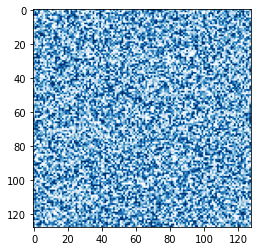

In [67]:
np.random.seed(0) 
grid = np.random.choice([0, 1, 2, 3, 4], size=(128, 128))

plt.imshow(grid, cmap='Blues')

neighbours_counts = compute_neighbours_counts(grid)
print("neighbours_counts (shape {}):".format(neighbours_counts.shape))
print(" Cell state | Num zeros | Num ones | Num twos | Num fours | Num fives")
for row in neighbours_counts:
    print(f"     {row[0]}              {row[1]}               {row[2]}              {row[3]}              {row[4]}              {row[5]}")

In [54]:
neighbours_counts

array([[0, 3, 3, 2],
       [1, 4, 2, 2],
       [0, 3, 3, 2],
       [1, 4, 2, 2],
       [1, 4, 2, 2],
       [2, 4, 3, 1],
       [0, 3, 3, 2],
       [2, 4, 3, 1],
       [0, 3, 3, 2]])